__Virtual Environment:__
- [requirements.txt](https://github.com/BredaUniversityADSAI/fae1-dele-1-2025-26-TimurKambarov250596/blob/main/Deliverables/requirements.txt)

Import python utilities for manipulation of images, plotting and numerical analysis.

In [1]:
import numpy as np
import tensorflow as tf
import keras
from keras.applications.imagenet_utils import decode_predictions
import skimage.io
import skimage.transform
import skimage.segmentation
import copy
import sklearn
import sklearn.metrics
from sklearn.linear_model import LinearRegression

print('Notebook running with:')
print('  TensorFlow:', tf.__version__)
print('  Keras:', keras.__version__)
np.random.seed(42)

Notebook running with:
  TensorFlow: 2.20.0
  Keras: 3.12.1


Initialize iteration 1 model (~95% test accuracy)

In [2]:
model = keras.models.load_model('i1_model.keras')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,383,901 (77.76 MB)

 Trainable params: 6,794,633 (25.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,589,268 (51.84 MB)

Load and process image

In [3]:
def get_img_array(img_path, size):
    # `img` is a PIL image resized for InceptionV3
    img = keras.utils.load_img(img_path, target_size=size)
    # `array` is a float32 Numpy array of shape (224, 224, 3)
    array = keras.utils.img_to_array(img).astype('float32')
    return array

img_size = tuple(model.input_shape[1:3])
img_path = '../raw_dataset/dataset/rotten_banana/Screen Shot 2018-06-12 at 9.19.42 PM.png'
img_array = get_img_array(img_path, size=img_size)
Xi = img_array.copy() / 255.0

Obtain predictions of the model

In [4]:
np.random.seed(42)
preds = model.predict(Xi[np.newaxis,:,:,:])
preds[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


array([0.0000000e+00, 6.4529336e-18, 4.3532203e-32, 1.6919893e-24,
       2.6224704e-12, 7.2739285e-27, 2.1964355e-28, 1.0000000e+00,
       3.4058559e-19], dtype=float32)

Create and plot image with highlighted superpixels

C:\Users\angel\AppData\Local\Temp\ipykernel_27748\2338298084.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(skimage.segmentation.mark_boundaries(Xi/2+0.5, superpixels))


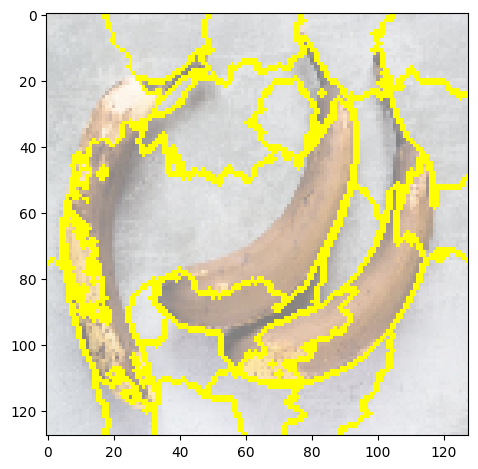

In [5]:
superpixels = skimage.segmentation.quickshift(Xi, kernel_size=3,max_dist=200, ratio=0.4)
num_superpixels = np.unique(superpixels).shape[0]
skimage.io.imshow(skimage.segmentation.mark_boundaries(Xi/2+0.5, superpixels))

Assign and apply random perturbations

In [6]:
num_perturb = 150
perturbations = np.random.binomial(1, 0.5, size=(num_perturb, num_superpixels))
perturbations[0] #Show example of perturbation

array([0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0], dtype=int32)

Plot an image with random perturbations

C:\Users\angel\AppData\Local\Temp\ipykernel_27748\2514827255.py:9: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(perturb_image(Xi/2+0.5,perturbations[0],superpixels))


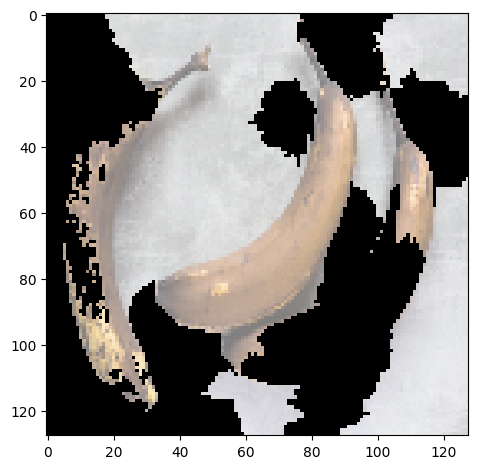

In [7]:
def perturb_image(img,perturbation,segments):
  active_pixels = np.where(perturbation == 1)[0]
  mask = np.zeros(segments.shape)
  for active in active_pixels:
      mask[segments == active] = 1
  perturbed_image = copy.deepcopy(img)
  perturbed_image = perturbed_image*mask[:,:,np.newaxis]
  return perturbed_image
skimage.io.imshow(perturb_image(Xi/2+0.5,perturbations[0],superpixels))

Use ML classifier to predict classes of new generated images

In [8]:
predictions = []
for pert in perturbations:
  perturbed_img = perturb_image(Xi,pert,superpixels)
  pred = model.predict(perturbed_img[np.newaxis,:,:,:])
  predictions.append(pred)

predictions = np.array(predictions)
predictions.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━

(150, 1, 9)

Compute distances between the original image and each of the perturbed images

In [9]:
original_image = np.ones(num_superpixels)[np.newaxis,:] #Perturbation with all superpixels enabled
distances = sklearn.metrics.pairwise_distances(perturbations,original_image, metric='cosine').ravel()
distances.shape

(150,)

Use kernel function to compute weights

In [10]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2)) #Kernel function
weights.shape

(150,)

Use perturbations, predictions and weights to fit a linear model

In [11]:
top_pred_classes = preds[0].argsort()[-5:][::-1]
class_to_explain = top_pred_classes[0]
simpler_model = LinearRegression()
simpler_model.fit(X=perturbations, y=predictions[:,:,class_to_explain], sample_weight=weights)
coeff = simpler_model.coef_[0]
coeff

array([-1.08005646e-07, -1.26212726e-07,  2.60998967e-07,  2.81869828e-07,
        1.85807025e-07,  7.94454000e-08,  9.73874337e-08, -2.32981275e-07,
       -1.89848724e-07, -1.15151590e-07,  5.09781448e-08, -7.51257201e-08,
       -3.31407023e-08,  2.34087785e-07, -1.85444625e-07,  1.56874393e-07,
        7.44895594e-08, -1.95725987e-08,  1.70130013e-07,  1.85974032e-07,
       -1.40886300e-07, -2.91445232e-08,  5.92107056e-08])

Compute top features (superpixels) and plot a LIME explanation

C:\Users\angel\AppData\Local\Temp\ipykernel_27748\3516513792.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(perturb_image(Xi/2+0.5,mask,superpixels) )


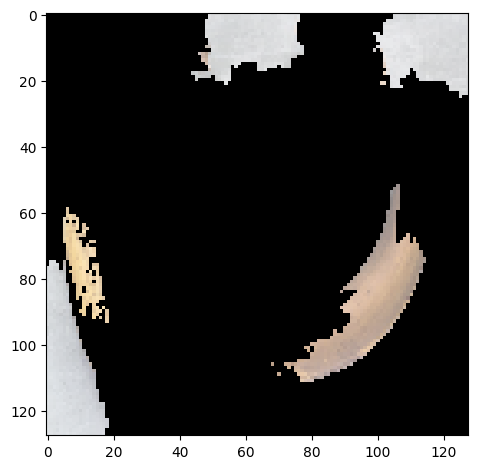

In [12]:
num_top_features = 4
top_features = np.argsort(coeff)[-num_top_features:]
mask = np.zeros(num_superpixels)
mask[top_features]= True #Activate top superpixels
skimage.io.imshow(perturb_image(Xi/2+0.5,mask,superpixels) )

The plotted image is a little complicated, as it contains both the main object (banana) and noise (background). If it would have been only background, or the majority would have been the background, then we could conclude the model is definitely biased. However, the ratio of main object and noise is around the same. Although the model is likely to be considired biased, as we can see the model highlights less than half of existing bananas, the rest is plain background.